# Milestone 2 — Data Preparation & Visualization Prototyping

**Project:** GenZvision — Gen Z Slang Evolution Tracker (2020–2025)  
**Goal:** Prepare aggregated JSON data files for the interactive D3.js website and create sketch-quality visualization prototypes.

This notebook:
1. Loads and preprocesses the raw dataset (reusing M1 logic)
2. Creates lightweight JSON aggregations for the web
3. Generates visualization prototypes that serve as sketches for the M2 report

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import json
import os

# Paths
RAW_DATA_PATH = r'C:\Users\marya\OneDrive\Documents\Dataviz\data\genz_slang_usage_2020_2025.csv'
OUTPUT_DIR = 'data'
WEBSITE_DATA_DIR = os.path.join('website', 'data')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(WEBSITE_DATA_DIR, exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Data Loading & Preprocessing
Reuse the cleaning logic from Milestone 1: parse timestamps, create time features, convert categoricals.

In [2]:
df = pd.read_csv(RAW_DATA_PATH)
print(f'Loaded {len(df):,} rows x {len(df.columns)} columns')

# Parse timestamps and create time features
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['year_month'] = df['timestamp'].dt.to_period('M').astype(str)

# Convert to categorical for efficiency
cat_cols = ['slang_term', 'term_category', 'origin_platform', 'usage_platform',
            'region', 'user_age_group', 'usage_context', 'lifecycle_phase', 'sentiment']
for col in cat_cols:
    df[col] = df[col].astype('category')

print(f'Date range: {df["timestamp"].min()} to {df["timestamp"].max()}')
print(f'Unique slang terms: {df["slang_term"].nunique()}')
print(f'Unique platforms (origin): {df["origin_platform"].nunique()}')
df.head()

Loaded 535,396 rows x 22 columns


Date range: 2020-01-01 01:23:17 to 2025-12-31 23:52:04
Unique slang terms: 46
Unique platforms (origin): 6


,record_id,timestamp,slang_term,term_category,term_meaning,origin_platform,usage_platform,region,user_id,user_age_group,...,ironic_usage,likes,shares,comments,virality_score,is_viral,days_since_emergence,year,month,year_month
0,0,2020-01-01 01:23:17,simp,insult,someone overly devoted to another person,Reddit,Twitter,California,user_019223,25-30,...,False,18,2,5,0.004,False,153,2020,1,2020-01
1,1,2020-01-01 03:21:59,simp,insult,someone overly devoted to another person,Reddit,Twitter,Texas,user_497341,13-17,...,False,24,1,2,0.004,False,153,2020,1,2020-01
2,2,2020-01-01 05:31:01,vibe check,social,checking someone's mood/energy,TikTok,TikTok,Canada,user_323563,31-40,...,False,121,1,0,0.013,False,92,2020,1,2020-01
3,3,2020-01-01 05:35:30,no cap,emphasis,"no lie, for real",Twitter,Twitter,Arizona,user_244857,18-24,...,False,47,2,1,0.006,False,214,2020,1,2020-01
4,4,2020-01-01 06:39:57,no cap,emphasis,"no lie, for real",Twitter,Instagram,Arizona,user_421848,13-17,...,False,18,0,14,0.006,False,214,2020,1,2020-01


## 2. Data Aggregation for the Web
Create lightweight JSON files that the D3.js website can load efficiently (target: <5MB total).

### 2.1 Slang Timeline — Monthly counts per term
For the timeline heatmap: terms (y-axis) x months (x-axis), color = count.

In [3]:
# Monthly usage count per slang term
timeline = df.groupby(['slang_term', 'year_month']).size().reset_index(name='count')

# Also compute average intensity and sentiment per term per month
timeline_agg = df.groupby(['slang_term', 'year_month']).agg(
    count=('record_id', 'size'),
    avg_intensity=('intensity_score', 'mean'),
    avg_sentiment=('sentiment_score', 'mean'),
    viral_count=('is_viral', 'sum')
).reset_index()

timeline_agg['avg_intensity'] = timeline_agg['avg_intensity'].round(3)
timeline_agg['avg_sentiment'] = timeline_agg['avg_sentiment'].round(3)

# Save as JSON
timeline_json = timeline_agg.to_dict(orient='records')
for path in [os.path.join(OUTPUT_DIR, 'slang_timeline.json'), os.path.join(WEBSITE_DATA_DIR, 'slang_timeline.json')]:
    with open(path, 'w') as f:
        json.dump(timeline_json, f)

print(f'Timeline: {len(timeline_json)} records, {os.path.getsize(os.path.join(OUTPUT_DIR, "slang_timeline.json")) / 1024:.1f} KB')

Timeline: 3312 records, 417.2 KB


C:\Users\marya\AppData\Local\Temp\ipykernel_19356\1516174405.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  timeline = df.groupby(['slang_term', 'year_month']).size().reset_index(name='count')
C:\Users\marya\AppData\Local\Temp\ipykernel_19356\1516174405.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  timeline_agg = df.groupby(['slang_term', 'year_month']).agg(


### 2.2 Platform Flow — Origin to Usage platform
For the Sankey diagram: shows how slang migrates between platforms.

In [4]:
# Platform flow: origin -> usage, with optional term filter
platform_flow = df.groupby(['origin_platform', 'usage_platform']).agg(
    count=('record_id', 'size'),
    avg_virality=('virality_score', 'mean'),
    avg_sentiment=('sentiment_score', 'mean')
).reset_index()

platform_flow['avg_virality'] = platform_flow['avg_virality'].round(4)
platform_flow['avg_sentiment'] = platform_flow['avg_sentiment'].round(3)

# Also create per-term platform flows for filtering
platform_flow_by_term = df.groupby(['slang_term', 'origin_platform', 'usage_platform']).size().reset_index(name='count')

flow_data = {
    'overall': platform_flow.to_dict(orient='records'),
    'by_term': platform_flow_by_term.to_dict(orient='records')
}

for path in [os.path.join(OUTPUT_DIR, 'platform_flow.json'), os.path.join(WEBSITE_DATA_DIR, 'platform_flow.json')]:
    with open(path, 'w') as f:
        json.dump(flow_data, f)

print(f'Platform flow: {len(flow_data["overall"])} overall + {len(flow_data["by_term"])} by-term records')
print(f'Size: {os.path.getsize(os.path.join(OUTPUT_DIR, "platform_flow.json")) / 1024:.1f} KB')

C:\Users\marya\AppData\Local\Temp\ipykernel_19356\275199893.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  platform_flow = df.groupby(['origin_platform', 'usage_platform']).agg(
C:\Users\marya\AppData\Local\Temp\ipykernel_19356\275199893.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  platform_flow_by_term = df.groupby(['slang_term', 'origin_platform', 'usage_platform']).size().reset_index(name='count')


Platform flow: 42 overall + 1932 by-term records
Size: 191.3 KB


### 2.3 Slang Lifecycle — Per-term metrics
For the bubble chart: each term's lifecycle trajectory.

In [5]:
# Per-term lifecycle summary
lifecycle = df.groupby('slang_term').agg(
    total_usage=('record_id', 'size'),
    first_seen=('timestamp', 'min'),
    last_seen=('timestamp', 'max'),
    peak_month=('year_month', lambda x: x.value_counts().idxmax()),
    dominant_phase=('lifecycle_phase', lambda x: x.value_counts().idxmax()),
    avg_intensity=('intensity_score', 'mean'),
    avg_sentiment=('sentiment_score', 'mean'),
    total_likes=('likes', 'sum'),
    total_shares=('shares', 'sum'),
    viral_posts=('is_viral', 'sum'),
    top_origin=('origin_platform', lambda x: x.value_counts().idxmax()),
    top_usage_platform=('usage_platform', lambda x: x.value_counts().idxmax()),
    term_category=('term_category', 'first'),
    term_meaning=('term_meaning', 'first')
).reset_index()

lifecycle['first_seen'] = lifecycle['first_seen'].dt.strftime('%Y-%m-%d')
lifecycle['last_seen'] = lifecycle['last_seen'].dt.strftime('%Y-%m-%d')
lifecycle['avg_intensity'] = lifecycle['avg_intensity'].round(3)
lifecycle['avg_sentiment'] = lifecycle['avg_sentiment'].round(3)

# Monthly trajectory per term (for animated bubble chart)
monthly_trajectory = df.groupby(['slang_term', 'year_month']).agg(
    count=('record_id', 'size'),
    phase=('lifecycle_phase', lambda x: x.value_counts().idxmax())
).reset_index()

lifecycle_data = {
    'summary': lifecycle.to_dict(orient='records'),
    'trajectory': monthly_trajectory.to_dict(orient='records')
}

for path in [os.path.join(OUTPUT_DIR, 'slang_lifecycle.json'), os.path.join(WEBSITE_DATA_DIR, 'slang_lifecycle.json')]:
    with open(path, 'w') as f:
        json.dump(lifecycle_data, f)

print(f'Lifecycle: {len(lifecycle)} terms')
print(f'Size: {os.path.getsize(os.path.join(OUTPUT_DIR, "slang_lifecycle.json")) / 1024:.1f} KB')
lifecycle.sort_values('total_usage', ascending=False).head(10)

C:\Users\marya\AppData\Local\Temp\ipykernel_19356\3276099588.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lifecycle = df.groupby('slang_term').agg(
C:\Users\marya\AppData\Local\Temp\ipykernel_19356\3276099588.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_trajectory = df.groupby(['slang_term', 'year_month']).agg(


Lifecycle: 46 terms
Size: 282.8 KB


,slang_term,total_usage,first_seen,last_seen,peak_month,dominant_phase,avg_intensity,avg_sentiment,total_likes,total_shares,viral_posts,top_origin,top_usage_platform,term_category,term_meaning
37,slay,19004,2020-08-01,2024-06-29,2023-01,growing,0.651,0.457,1312366,71113,26,TikTok,TikTok,approval,doing something exceptionally well
4,based,18541,2020-09-01,2024-06-28,2022-10,growing,0.653,0.453,946035,49810,22,Reddit,Reddit,approval,"authentic, not caring about opinions"
8,bussin,17651,2020-01-01,2023-08-28,2021-03,growing,0.653,0.451,1201913,63996,19,TikTok,TikTok,approval,"really good, especially food"
31,rizz,16782,2022-01-01,2025-06-30,2023-05,growing,0.649,0.292,1162594,60996,25,TikTok,TikTok,attraction,"charisma, ability to attract others"
16,gaslighting,16766,2021-04-01,2024-09-28,2023-05,growing,0.646,-0.447,1145380,63298,22,TikTok,TikTok,manipulation,psychological manipulation
33,sigma,15630,2023-03-01,2025-12-31,2024-08,growing,0.687,0.260,951979,51910,19,YouTube,YouTube,identity,lone wolf personality type
2,ate,15626,2021-05-01,2024-07-30,2022-03,declining,0.652,0.457,837011,42509,21,Twitter,Twitter,approval,"did really well, killed it"
12,delulu,15244,2022-10-01,2025-11-27,2023-05,declining,0.650,-0.343,1063688,56571,23,TikTok,TikTok,insult,"delusional, unrealistic expectations"
38,snatched,15201,2021-09-01,2024-10-28,2023-08,growing,0.647,0.346,910067,45661,15,Instagram,Instagram,appearance,"looking really good, on point"
27,no cap,15107,2020-01-01,2022-11-28,2020-03,declining,0.688,0.253,831139,45135,17,Twitter,Twitter,emphasis,"no lie, for real"


### 2.4 Regional Data
For potential choropleth map (stretch goal).

In [6]:
regional = df.groupby('region').agg(
    total_usage=('record_id', 'size'),
    unique_terms=('slang_term', 'nunique'),
    avg_sentiment=('sentiment_score', 'mean'),
    top_term=('slang_term', lambda x: x.value_counts().idxmax()),
    top_platform=('usage_platform', lambda x: x.value_counts().idxmax())
).reset_index()

regional['avg_sentiment'] = regional['avg_sentiment'].round(3)

regional_json = regional.to_dict(orient='records')
for path in [os.path.join(OUTPUT_DIR, 'regional_data.json'), os.path.join(WEBSITE_DATA_DIR, 'regional_data.json')]:
    with open(path, 'w') as f:
        json.dump(regional_json, f)

print(f'Regional: {len(regional_json)} regions')
regional.sort_values('total_usage', ascending=False).head(10)

Regional: 22 regions


C:\Users\marya\AppData\Local\Temp\ipykernel_19356\227824545.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regional = df.groupby('region').agg(


,region,total_usage,unique_terms,avg_sentiment,top_term,top_platform
3,California,64047,46,0.177,slay,TikTok
13,New York,53272,46,0.174,slay,TikTok
19,Texas,48279,46,0.172,slay,TikTok
20,UK,42763,46,0.174,slay,TikTok
6,Florida,37550,46,0.174,based,TikTok
9,Illinois,27159,46,0.179,based,TikTok
10,India,26727,46,0.172,based,TikTok
4,Canada,26624,46,0.176,slay,TikTok
1,Australia,21636,46,0.172,slay,TikTok
7,Georgia,21395,46,0.179,based,TikTok


### 2.5 Top Terms Summary
Quick-access summary for the hero section and filters.

In [7]:
top_terms = lifecycle.sort_values('total_usage', ascending=False).head(20)
top_terms_json = top_terms[['slang_term', 'total_usage', 'term_category', 'term_meaning',
                            'dominant_phase', 'peak_month', 'top_origin', 'avg_sentiment']].to_dict(orient='records')

for path in [os.path.join(OUTPUT_DIR, 'top_terms_summary.json'), os.path.join(WEBSITE_DATA_DIR, 'top_terms_summary.json')]:
    with open(path, 'w') as f:
        json.dump(top_terms_json, f)

print(f'Top terms: {len(top_terms_json)} terms')

# Total data size
total_size = sum(os.path.getsize(os.path.join(OUTPUT_DIR, f)) for f in os.listdir(OUTPUT_DIR) if f.endswith('.json'))
print(f'\nTotal JSON data size: {total_size / 1024:.1f} KB ({total_size / (1024*1024):.2f} MB)')

Top terms: 20 terms

Total JSON data size: 898.8 KB (0.88 MB)


## 3. Visualization Prototypes
These serve as sketches for the M2 report and inform the D3.js implementation.

### 3.1 Timeline Heatmap — Term Popularity Over Time
**Section 2 of the website:** Shows when each slang term rises and falls.  
Uses: sequential colormap (L6.1), position channel for time (L6.2), D3 scales & axes (L5.2).

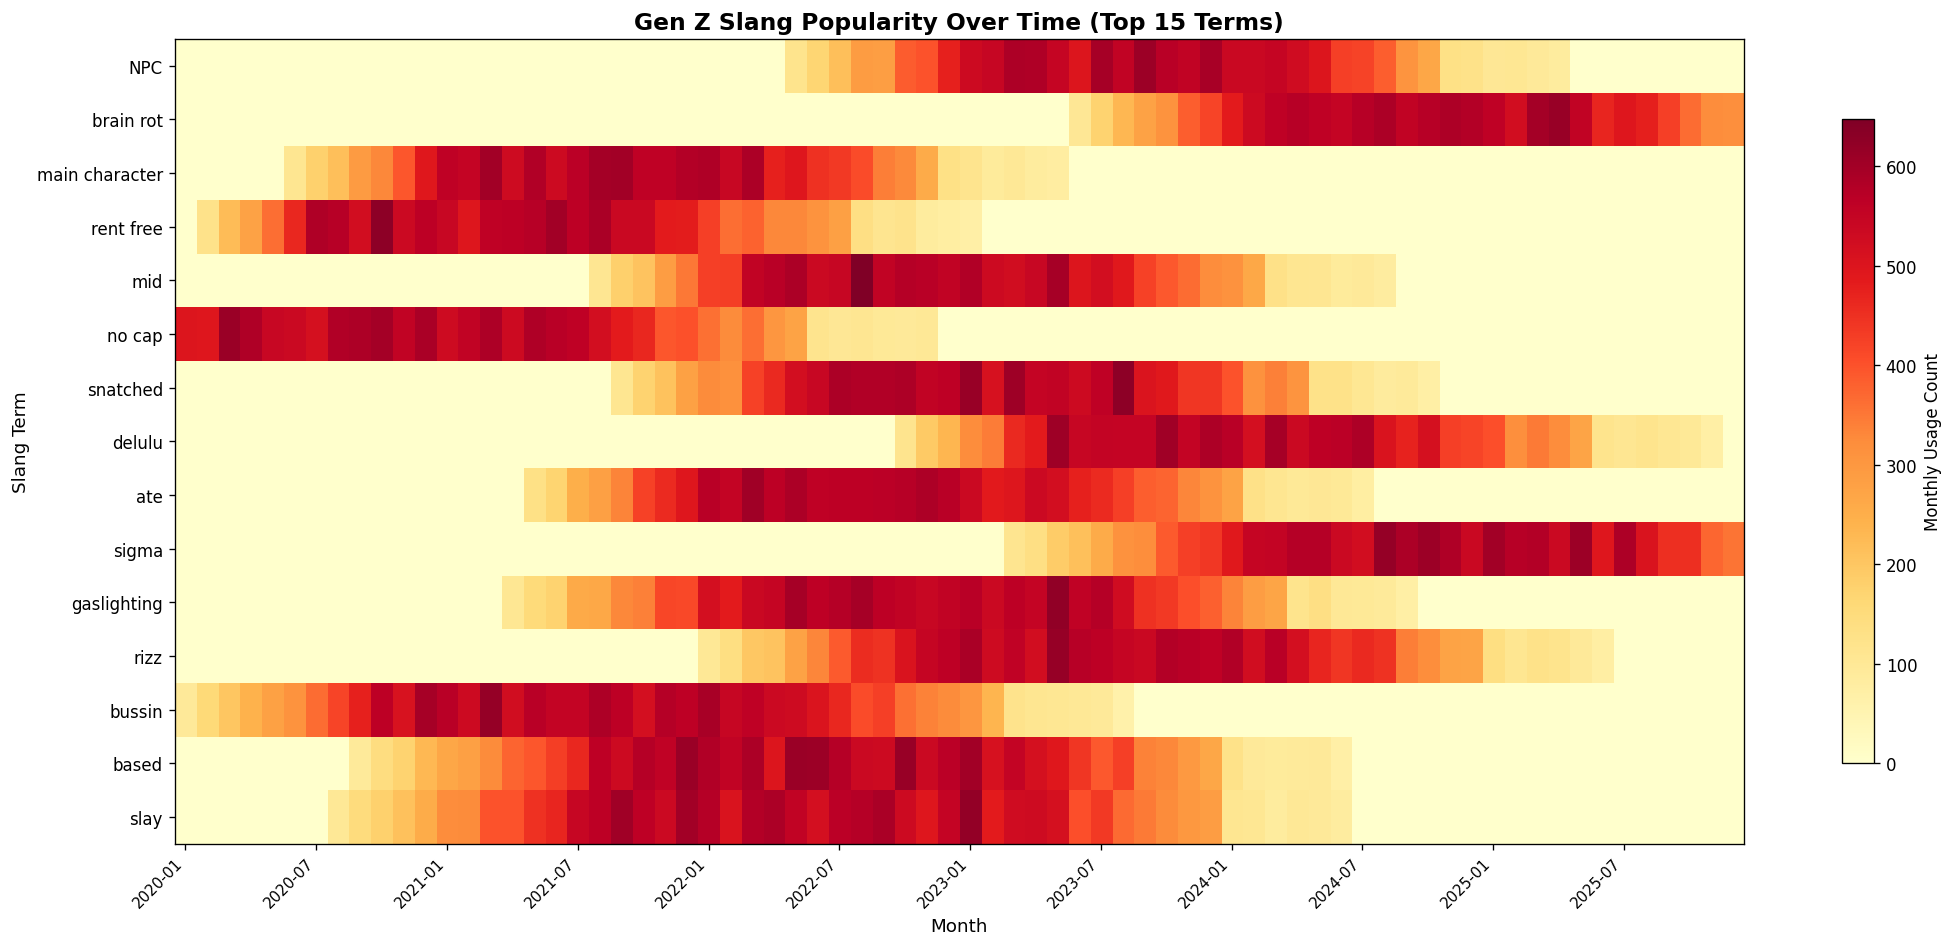

Saved: data/sketch_timeline_heatmap.png


In [8]:
# Pivot: terms x months
top_15 = df['slang_term'].value_counts().head(15).index.tolist()
heatmap_data = timeline_agg[timeline_agg['slang_term'].isin(top_15)].pivot(
    index='slang_term', columns='year_month', values='count'
).fillna(0)

# Sort by total usage
heatmap_data = heatmap_data.loc[heatmap_data.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(18, 8))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')

# Labels
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=10)

# Show every 6th month on x-axis
month_labels = heatmap_data.columns.tolist()
tick_positions = list(range(0, len(month_labels), 6))
ax.set_xticks(tick_positions)
ax.set_xticklabels([month_labels[i] for i in tick_positions], rotation=45, ha='right', fontsize=9)

ax.set_title('Gen Z Slang Popularity Over Time (Top 15 Terms)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Slang Term', fontsize=11)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Monthly Usage Count', fontsize=10)

plt.tight_layout()
plt.savefig('data/sketch_timeline_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/sketch_timeline_heatmap.png')

### 3.2 Platform Sankey — Cross-Platform Diffusion
**Section 3 of the website:** Shows how slang flows from origin platforms to usage platforms.  
Uses: Sankey as "multivariate representation of movement" (L8), brushing & linking (L5.1).

C:\Users\marya\AppData\Local\Temp\ipykernel_19356\3733666023.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  origin_counts = flow_df.groupby('origin_platform')['count'].sum().sort_values()
C:\Users\marya\AppData\Local\Temp\ipykernel_19356\3733666023.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  usage_counts = flow_df.groupby('usage_platform')['count'].sum().sort_values()


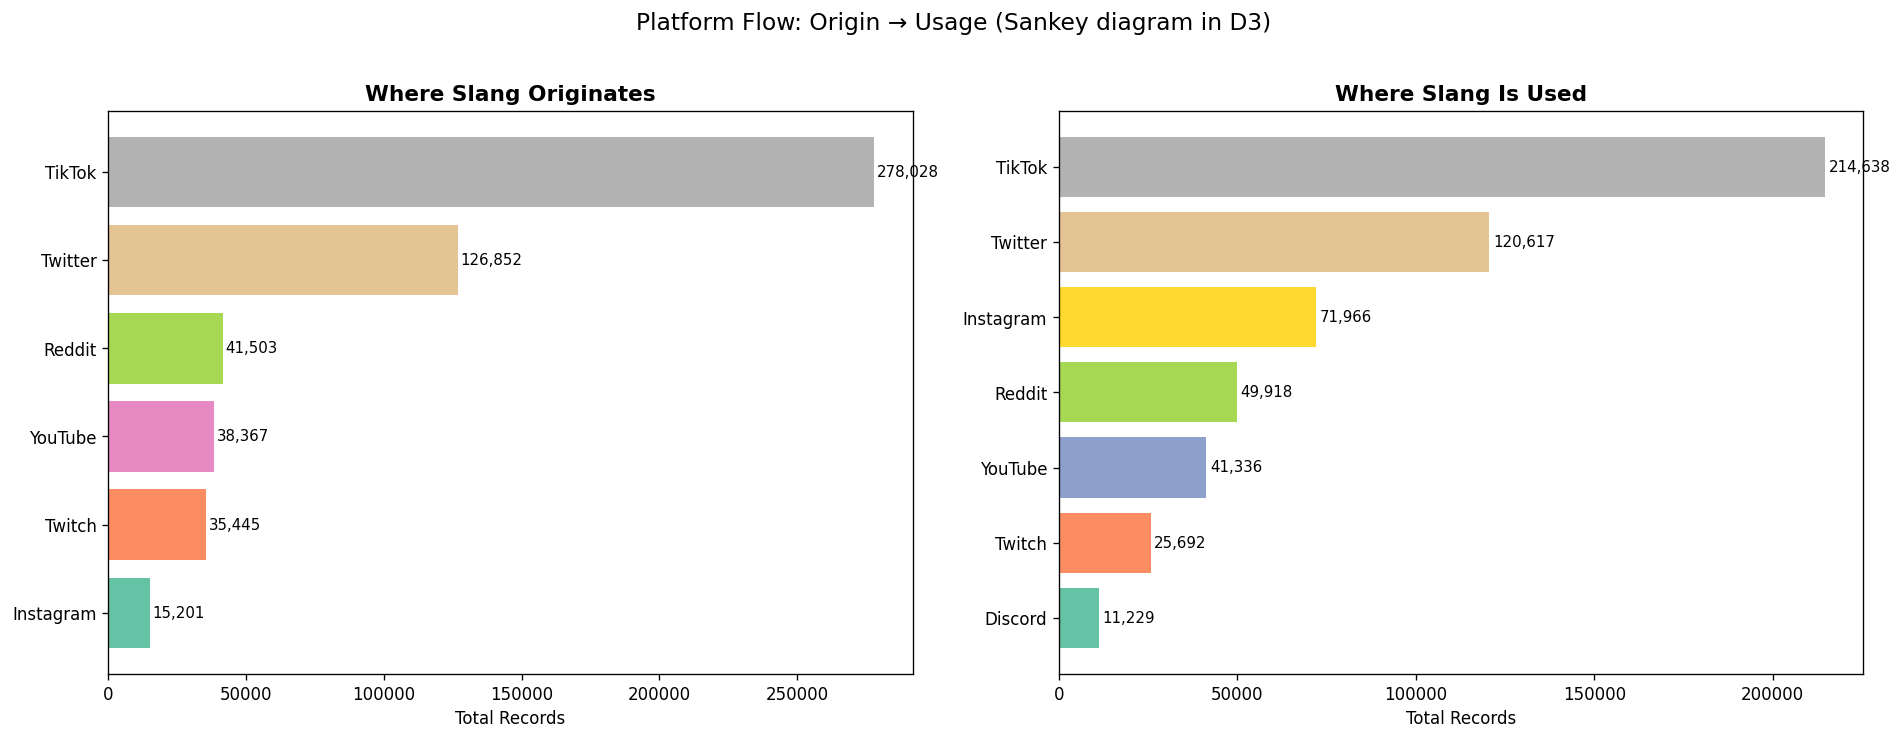

Saved: data/sketch_platform_flow.png

Cross-platform flow matrix:


usage_platform,Discord,Instagram,Reddit,TikTok,Twitch,Twitter,YouTube
origin_platform,,,,,,,
Instagram,285,6496,1108,3734,402,2350,826
Reddit,912,5224,15288,10334,1139,6285,2321
TikTok,5761,35024,19385,151597,7795,42832,15634
Twitch,737,4467,2491,8680,11697,5461,1912
Twitter,2767,16004,8806,30857,3577,57760,7081
YouTube,767,4751,2840,9436,1082,5929,13562


In [9]:
# Simple bar-based sketch of platform flows (Sankey will be in D3)
flow_df = platform_flow.copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Origin platform distribution
origin_counts = flow_df.groupby('origin_platform')['count'].sum().sort_values()
colors_origin = plt.cm.Set2(np.linspace(0, 1, len(origin_counts)))
axes[0].barh(origin_counts.index, origin_counts.values, color=colors_origin)
axes[0].set_title('Where Slang Originates', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Records')
for i, v in enumerate(origin_counts.values):
    axes[0].text(v + 1000, i, f'{v:,}', va='center', fontsize=9)

# Right: Usage platform distribution
usage_counts = flow_df.groupby('usage_platform')['count'].sum().sort_values()
colors_usage = plt.cm.Set2(np.linspace(0, 1, len(usage_counts)))
axes[1].barh(usage_counts.index, usage_counts.values, color=colors_usage)
axes[1].set_title('Where Slang Is Used', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Records')
for i, v in enumerate(usage_counts.values):
    axes[1].text(v + 1000, i, f'{v:,}', va='center', fontsize=9)

plt.suptitle('Platform Flow: Origin → Usage (Sankey diagram in D3)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('data/sketch_platform_flow.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/sketch_platform_flow.png')

# Cross-platform matrix
cross = flow_df.pivot(index='origin_platform', columns='usage_platform', values='count').fillna(0)
print('\nCross-platform flow matrix:')
cross

### 3.3 Bubble Chart — Term Lifecycle
**Section 4 of the website:** Animated bubbles showing terms rising and falling.  
Uses: D3 transitions & easing (L5.2), force-directed layouts (L10), narrative structure (L12).

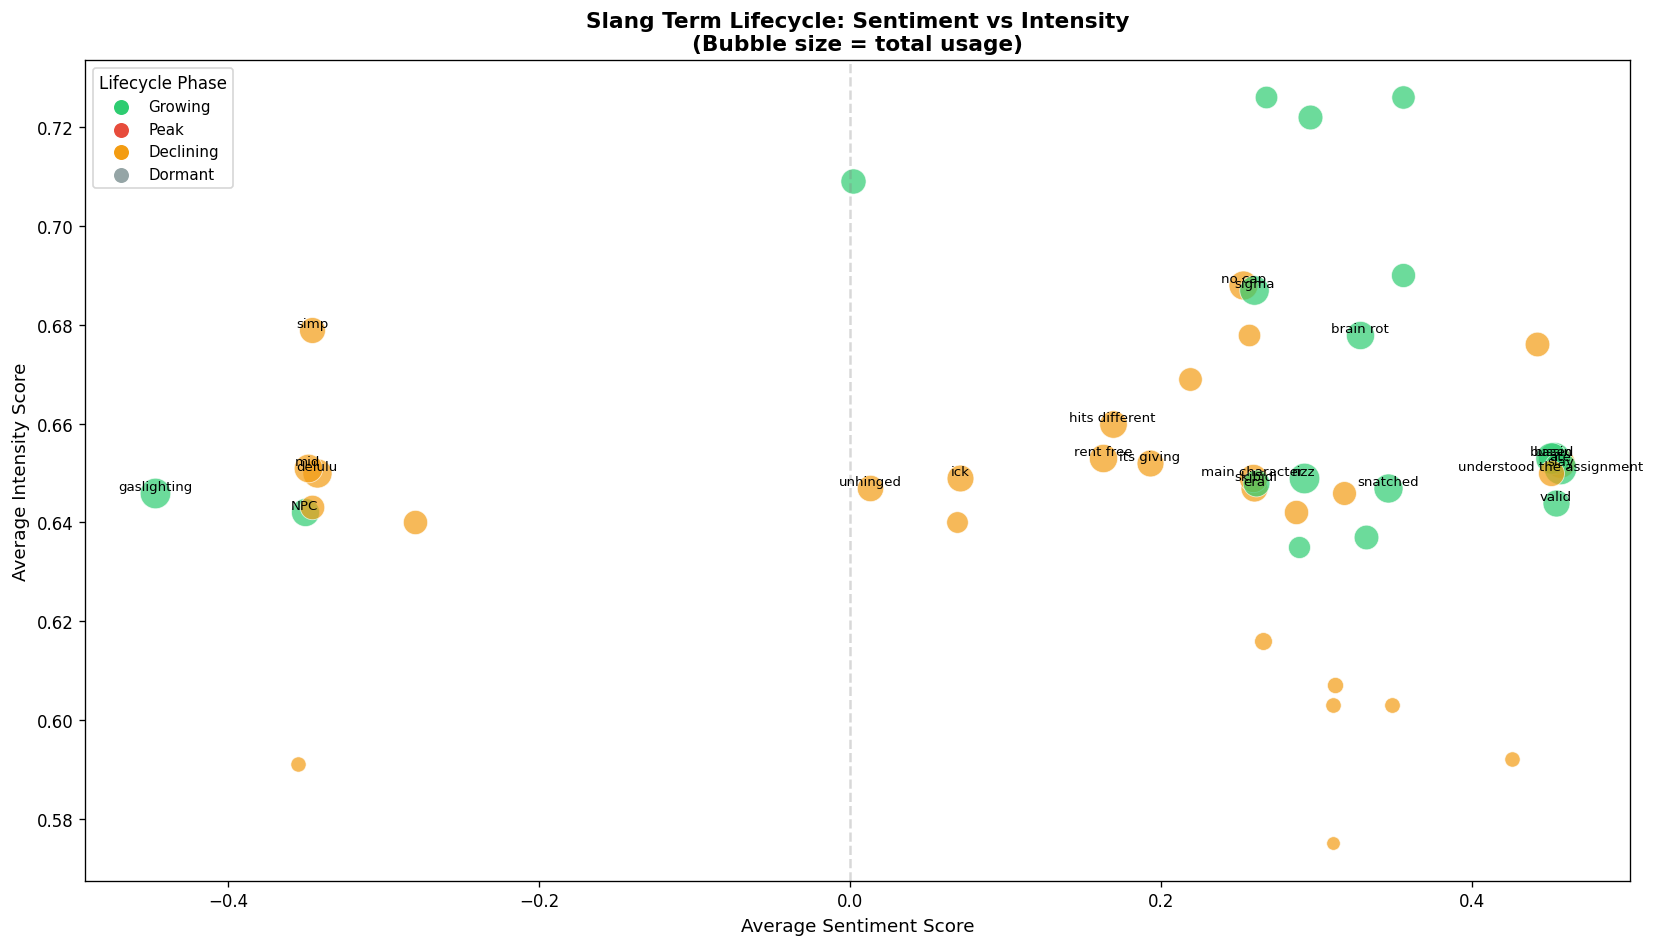

Saved: data/sketch_bubble_lifecycle.png


In [10]:
# Bubble chart: size = total usage, color = dominant phase, x = avg sentiment
phase_colors = {'growing': '#2ecc71', 'peak': '#e74c3c', 'declining': '#f39c12', 'dormant': '#95a5a6'}

fig, ax = plt.subplots(figsize=(14, 8))

for _, row in lifecycle.iterrows():
    color = phase_colors.get(row['dominant_phase'], '#333')
    size = row['total_usage'] / 50  # scale down
    ax.scatter(row['avg_sentiment'], row['avg_intensity'],
              s=size, c=color, alpha=0.7, edgecolors='white', linewidth=0.5)
    if row['total_usage'] > 12000:  # label top terms
        ax.annotate(row['slang_term'], (row['avg_sentiment'], row['avg_intensity']),
                   fontsize=8, ha='center', va='bottom')

# Legend
for phase, color in phase_colors.items():
    ax.scatter([], [], c=color, s=100, label=phase.capitalize(), edgecolors='white')
ax.legend(title='Lifecycle Phase', loc='upper left', fontsize=9)

ax.set_xlabel('Average Sentiment Score', fontsize=11)
ax.set_ylabel('Average Intensity Score', fontsize=11)
ax.set_title('Slang Term Lifecycle: Sentiment vs Intensity\n(Bubble size = total usage)', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('data/sketch_bubble_lifecycle.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/sketch_bubble_lifecycle.png')

### 3.4 Sentiment Distribution
Additional context for the narrative — how positive/negative is Gen Z slang?

C:\Users\marya\AppData\Local\Temp\ipykernel_19356\345621374.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sent_by_cat = df.groupby(['term_category', 'sentiment']).size().unstack(fill_value=0)


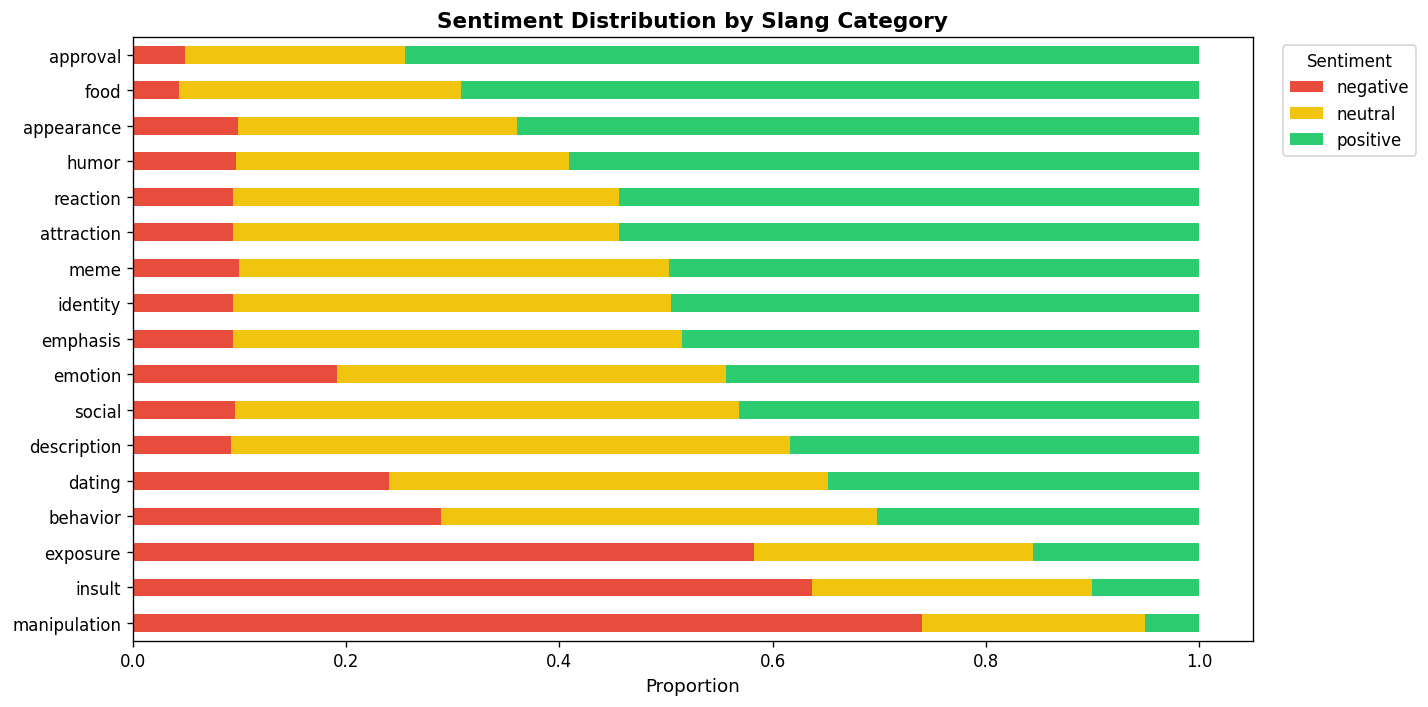

Saved: data/sketch_sentiment.png


In [11]:
# Sentiment by term category
sent_by_cat = df.groupby(['term_category', 'sentiment']).size().unstack(fill_value=0)
sent_by_cat_pct = sent_by_cat.div(sent_by_cat.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
sent_by_cat_pct.sort_values('positive').plot(
    kind='barh', stacked=True, ax=ax,
    color={'positive': '#2ecc71', 'neutral': '#f1c40f', 'negative': '#e74c3c'}
)
ax.set_xlabel('Proportion', fontsize=11)
ax.set_ylabel('')
ax.set_title('Sentiment Distribution by Slang Category', fontsize=13, fontweight='bold')
ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('data/sketch_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/sketch_sentiment.png')

### 3.5 Regional Distribution
Sketch for potential choropleth (stretch goal).  
Uses: choropleth concept from L8 — "areas shaded in proportion to measurement".

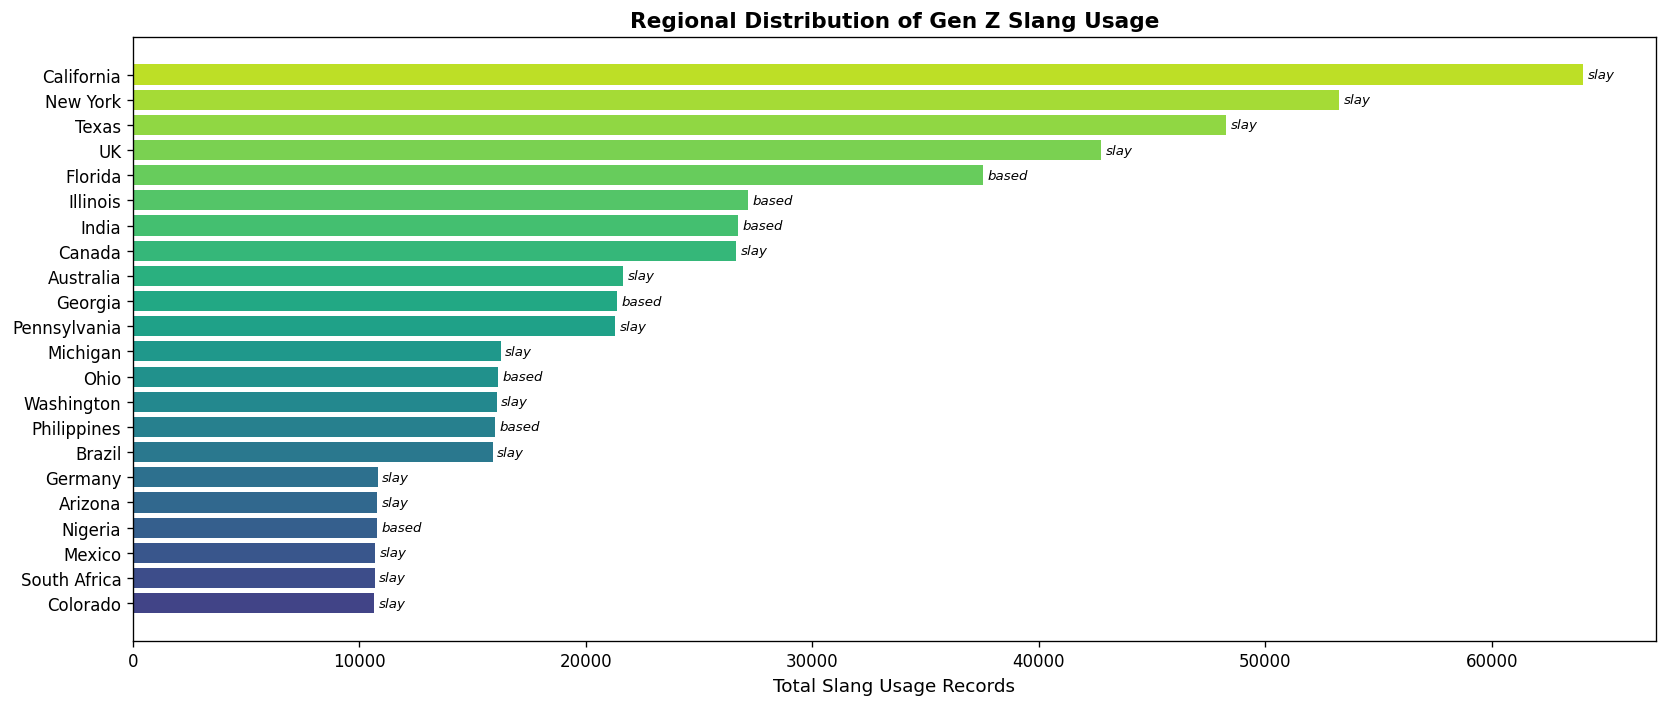

Saved: data/sketch_regional.png


In [12]:
fig, ax = plt.subplots(figsize=(14, 6))
reg_sorted = regional.sort_values('total_usage', ascending=True)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(reg_sorted)))
ax.barh(reg_sorted['region'], reg_sorted['total_usage'], color=colors)
ax.set_xlabel('Total Slang Usage Records', fontsize=11)
ax.set_title('Regional Distribution of Gen Z Slang Usage', fontsize=13, fontweight='bold')

for i, (_, row) in enumerate(reg_sorted.iterrows()):
    ax.text(row['total_usage'] + 200, i, f"{row['top_term']}", fontsize=8, va='center', style='italic')

plt.tight_layout()
plt.savefig('data/sketch_regional.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/sketch_regional.png')

## 4. Key Data Insights for the Narrative
Summary of findings that will structure the scrollytelling website.

In [13]:
print('=== KEY INSIGHTS FOR NARRATIVE ===')
print()

# The Rise
print('--- SECTION 2: THE RISE ---')
top5 = lifecycle.nlargest(5, 'total_usage')
print(f'Most popular terms: {", ".join(top5["slang_term"].tolist())}')
print(f'Dataset spans {df["year"].min()} to {df["year"].max()}')
print(f'Total unique terms tracked: {df["slang_term"].nunique()}')
print()

# The Spread
print('--- SECTION 3: THE SPREAD ---')
origin_dom = df['origin_platform'].value_counts()
print(f'Top origin platform: {origin_dom.index[0]} ({origin_dom.iloc[0]/len(df)*100:.1f}%)')
usage_dom = df['usage_platform'].value_counts()
print(f'Top usage platform: {usage_dom.index[0]} ({usage_dom.iloc[0]/len(df)*100:.1f}%)')
print(f'Key insight: Discord appears only as usage platform, not origin — pure adoption platform')
print()

# The Peak & Decline
print('--- SECTION 4: PEAK & DECLINE ---')
phase_dist = df['lifecycle_phase'].value_counts()
for phase, count in phase_dist.items():
    print(f'  {phase}: {count:,} records ({count/len(df)*100:.1f}%)')
print(f'Ironic usage rate: {df["ironic_usage"].mean()*100:.1f}%')
print(f'Viral post rate: {df["is_viral"].mean()*100:.2f}%')
print()

# Explore
print('--- SECTION 5: EXPLORE ---')
print(f'Age groups: {df["user_age_group"].unique().tolist()}')
print(f'Dominant age group: {df["user_age_group"].value_counts().index[0]}')
print(f'Regions: {df["region"].nunique()}')
print(f'Usage contexts: {df["usage_context"].nunique()}')

=== KEY INSIGHTS FOR NARRATIVE ===

--- SECTION 2: THE RISE ---
Most popular terms: slay, based, bussin, rizz, gaslighting
Dataset spans 2020 to 2025
Total unique terms tracked: 46

--- SECTION 3: THE SPREAD ---
Top origin platform: TikTok (51.9%)
Top usage platform: TikTok (40.1%)
Key insight: Discord appears only as usage platform, not origin — pure adoption platform

--- SECTION 4: PEAK & DECLINE ---
  declining: 203,431 records (38.0%)
  growing: 191,988 records (35.9%)
  peak: 116,481 records (21.8%)
  legacy: 23,496 records (4.4%)
Ironic usage rate: 10.9%
Viral post rate: 0.13%

--- SECTION 5: EXPLORE ---
Age groups: ['25-30', '13-17', '31-40', '18-24', '41+']
Dominant age group: 18-24
Regions: 22
Usage contexts: 17
